In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
DATA_PATH = "./"

# Phân tích file `training_dataset_labeled_period.csv` có khoảng thời gian từ 17/04/2026 - 12/05/2026

## Phân tích tổng quan

In [3]:
df_train = pd.read_csv(DATA_PATH + 'test_flight_filtered.csv')
df_train.head()

,retrieved_at_vn,flight_date,direction,scheduled_time,estimated_time,route_airport,flight_number,status_raw,source_airport,route_airport_std,...,delta_temperature_c,delta_dew_point_c,delta_wind_speed_kt,delta_visibility_miles,lag_delay_mean_airline_1h,lag_delay_mean_airline_3h,lag_delay_mean_airline_6h,lag_delay_mean_route_1d,lag_delay_mean_route_7d,airport_congestion
0,2026-04-17 22:01:45,2026-04-17,Arrival,08:20,08:19,Hà Nội (HAN),9G907,Đã đến,DN,HA NOI (HAN),...,0.0,0.0,0.0,0.0,0.000,-2.500000,-2.500000,-1.500000,-1.500000,20.0
1,2026-05-11 19:28:32,2026-05-11,Departure,10:10,10:10,HO CHI MINH,QH211,Departed,NB,HO CHI MINH,...,0.0,0.0,0.0,0.0,0.000,0.000000,-1.500000,-0.440000,0.993750,31.0
2,2026-04-17 22:01:45,2026-04-17,Arrival,21:30,21:29,Cần Thơ (VCA),VJ704,Đã đến,DN,CAN THO (VCA),...,NaN,NaN,NaN,NaN,37.375,45.166667,30.040816,-1.333333,-1.333333,17.0
3,2026-04-17 22:01:35,2026-04-17,Arrival,21:35,21:55,Chu Lai,VJ377,Đã hạ cánh,TSN,CHU LAI,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2026-04-17 22:01:35,2026-04-17,Departure,21:20,22:00,Huế,VJ311,Đã hạ cánh,TSN,HUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
selected_columns = [
    'flight_date', 'direction', 'flight_number', 'source_airport', 
    'route_airport_std', 'status_group', 'scheduled_dt', 'estimated_dt', 
    'delay_minutes', 'label_delay', 'icao_code', 'temperature_c', 
    'dew_point_c', 'wind_direction_deg', 'wind_speed_kt', 'visibility_miles', 
    'cloud_cover', 'is_wind_variable', 'scheduled_hour', 'scheduled_dayofweek', 
    'scheduled_month', 'airline_code', 'minutes_to_departure_at_snapshot', 
    'temp_dew_spread', 'is_low_visibility'
]

df_train = df_train[selected_columns]

In [5]:
df_train

,flight_date,direction,flight_number,source_airport,route_airport_std,status_group,scheduled_dt,estimated_dt,delay_minutes,label_delay,...,visibility_miles,cloud_cover,is_wind_variable,scheduled_hour,scheduled_dayofweek,scheduled_month,airline_code,minutes_to_departure_at_snapshot,temp_dew_spread,is_low_visibility
0,2026-04-17,Arrival,9G907,DN,HA NOI (HAN),other,2026-04-17 08:20:00,2026-04-17 08:19:00,-1.0,0,...,6.0,BKN@800ft,0,8,4,4,9G,-821.750000,2,0.0
1,2026-05-11,Departure,QH211,NB,HO CHI MINH,departed,2026-05-11 10:10:00,2026-05-11 10:10:00,0.0,0,...,6.0,clear,0,10,0,5,QH,-558.533333,4,0.0
2,2026-04-17,Arrival,VJ704,DN,CAN THO (VCA),other,2026-04-17 21:30:00,2026-04-17 21:29:00,-1.0,0,...,6.0,BKN@800ft,0,21,4,4,VJ,-31.750000,2,0.0
3,2026-04-17,Arrival,VJ377,TSN,CHU LAI,landed,2026-04-17 21:35:00,2026-04-17 21:55:00,20.0,1,...,6.0,clear,0,21,4,4,VJ,-26.583333,7,0.0
4,2026-04-17,Departure,VJ311,TSN,HUE,landed,2026-04-17 21:20:00,2026-04-17 22:00:00,40.0,1,...,6.0,clear,0,21,4,4,VJ,-41.583333,7,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11640,2026-05-12,Departure,VN220,TSN,HA NOI,other,2026-05-12 20:00:00,2026-05-12 20:00:00,0.0,0,...,6.0,clear,0,20,1,5,VN,36.466667,7,0.0
11641,2026-05-12,Departure,VN270,TSN,HA NOI,other,2026-05-12 23:00:00,2026-05-12 23:00:00,0.0,0,...,6.0,clear,0,23,1,5,VN,216.466667,7,0.0
11642,2026-05-12,Departure,VN1188,TSN,HAI PHONG,other,2026-05-12 21:00:00,2026-05-12 21:00:00,0.0,0,...,6.0,clear,0,21,1,5,VN,96.466667,7,0.0
11643,2026-05-12,Departure,VJ168,TSN,HA NOI,other,2026-05-12 23:00:00,2026-05-12 23:00:00,0.0,0,...,6.0,clear,0,23,1,5,VJ,216.466667,7,0.0


### Tổng quan dữ liệu

In [6]:
print(f"Số lượng dòng: {df_train.shape[0]}")
print(f"Số lượng cột: {df_train.shape[1]}")
print(df_train.info())

Số lượng dòng: 11645
Số lượng cột: 25
<class 'pandas.DataFrame'>
RangeIndex: 11645 entries, 0 to 11644
Data columns (total 25 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   flight_date                       11645 non-null  str    
 1   direction                         11645 non-null  str    
 2   flight_number                     11645 non-null  str    
 3   source_airport                    11645 non-null  str    
 4   route_airport_std                 11645 non-null  str    
 5   status_group                      11645 non-null  str    
 6   scheduled_dt                      11645 non-null  str    
 7   estimated_dt                      9774 non-null   str    
 8   delay_minutes                     9774 non-null   float64
 9   label_delay                       11645 non-null  int64  
 10  icao_code                         11645 non-null  str    
 11  temperature_c                     11645 

### Giá trị bị thiếu

In [7]:
# Liệt kê các cột có giá trị thiếu và tỷ lệ %
missing = df_train.isnull().sum()
missing = missing[missing > 0]
if not missing.empty:
    print(pd.DataFrame({'Số lượng': missing, 'Tỷ lệ (%)': (missing/len(df_train)*100).round(2)}))
else:
    print("Không có giá trị thiếu.")

                    Số lượng  Tỷ lệ (%)
estimated_dt            1871      16.07
delay_minutes           1871      16.07
wind_direction_deg      1771      15.21
airline_code               1       0.01
is_low_visibility         55       0.47


- Thiếu hụt nhiều nhất: `estimated_dt` và `delay_minutes` cùng thiếu đến 16.09% và cả 2 đều cũng thiếu cùng số dòng. Điều này đã được làm rõ vì `delay_minutes` được lấy từ dữ liệu `estimated_dt` cho nên khi cột này thiếu thì `delay_minutes` cũng sẽ thiếu.

- Dữ liệu `wind_direction_deg` bị thiếu 15.23%, cho thấy sẽ giảm độ tin cậy khi sử dụng biến này để dự đoán và cần kiểm tra xem tại sao lại bị thiếu hụt như vậy.

- Các dữ liệu thiếu ít như là `airline_code` hay là `is_low_visibility` chỉ 1 và 55 dòng -> có thể bỏ qua khi đưa vào mô hình huấn luyện 

### Dữ liệu trùng lặp

In [8]:
duplicate_count = df_train.duplicated().sum()
print(f"Số lượng dòng trùng lặp: {duplicate_count}")
if duplicate_count > 0:
    df_train = df_train.drop_duplicates()

Số lượng dòng trùng lặp: 0


### Phân tích các cột Numerical

In [9]:
desc = df_train.describe().T
desc

,count,mean,std,min,25%,50%,75%,max
delay_minutes,9774.0,5.424494,23.043306,-345.000000,0.000000,0.000000,5.000000,471.000000
label_delay,11645.0,0.140919,0.347953,0.000000,0.000000,0.000000,0.000000,1.000000
temperature_c,11645.0,27.290769,2.433899,19.000000,26.000000,27.000000,29.000000,36.000000
dew_point_c,11645.0,22.693946,2.207449,14.000000,22.000000,23.000000,24.000000,26.000000
wind_direction_deg,9874.0,141.971845,88.002185,0.000000,80.000000,130.000000,170.000000,360.000000
wind_speed_kt,11645.0,5.291627,3.119123,0.000000,3.000000,5.000000,8.000000,17.000000
visibility_miles,11645.0,5.718296,0.784792,1.370000,6.000000,6.000000,6.000000,6.000000
is_wind_variable,11645.0,0.152082,0.359116,0.000000,0.000000,0.000000,0.000000,1.000000
scheduled_hour,11645.0,13.684414,5.132454,0.000000,10.000000,14.000000,18.000000,23.000000
scheduled_dayofweek,11645.0,3.090425,2.120911,0.000000,1.000000,3.000000,5.000000,6.000000


**Giá trị ngoại lai (Outliers)**: 
- `delay_minutes` có tồn tại giá trị âm bất thường (-345) hoặc dương bất thường (+471) cần được kiểm tra.

**Các yếu tố thời tiết**
- Độ ẩm rất cao: Chênh lệch `temperature_c` và `temp_dew_spread` thấp, cho thấy không khí rất ẩm.

- `visibility_miles`: Đa số là 6 dặm (đây có thể là giới hạn ghi nhận tối đa của trạm đo). Tuy nhiên, có lúc giảm xuống 1.37 dặm. Chỉ có khoảng 2.9% trường hợp được coi là tầm nhìn thấp (`is_low_visibility`)

**Các yếu tố thời gian**
- `scheduled_hour`: tập trung nhiều nhất vào khoảng 14h

- `scheduled_month`: tập dữ liệu chỉ xoay quanh tháng 4,5 của năm nay -> không thể thể hiện các quy luật cho cả năm, chỉ có thể theo dõi theo hàng tuần hay hàng ngày.

### Phân tích các cột Categorical

In [10]:
categorical_cols = df_train.select_dtypes(include=['object', 'str']).columns
for col in categorical_cols:
    print(f"{col:<18}: {df_train[col].nunique():>4} giá trị khác nhau")

flight_date       :   26 giá trị khác nhau
direction         :    2 giá trị khác nhau
flight_number     : 1000 giá trị khác nhau
source_airport    :    3 giá trị khác nhau
route_airport_std :   79 giá trị khác nhau
status_group      :    5 giá trị khác nhau
scheduled_dt      : 5033 giá trị khác nhau
estimated_dt      : 6682 giá trị khác nhau
icao_code         :    3 giá trị khác nhau
cloud_cover       :  289 giá trị khác nhau
airline_code      :   36 giá trị khác nhau


1. Nhóm Low Cardinality
- `direction`, `source_airport`, `icao_code` `status_group`: có độ đa dạng thấp -> có thể One-hot Encoding.

- `airline_code` là số lượng hãng bay được dùng để thay thế cho `flight_number` số hiệu chuyến bay.

2. Nhóm dữ liệu thời gian
- `scheduled_dt`, `estimated_dt` -> Không đưa trực tiếp vào mô hình, sẽ dùng các cột được tách sẵn như `scheduled_hour`. `scheduled_dayofweek` có độ đa dạng thấp và mang tính quy luật hơn.

### Phân tích cột Label

C:\Users\vnviv\AppData\Local\Temp\ipykernel_44040\3213847593.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='label_delay', data=df_train, palette='viridis')


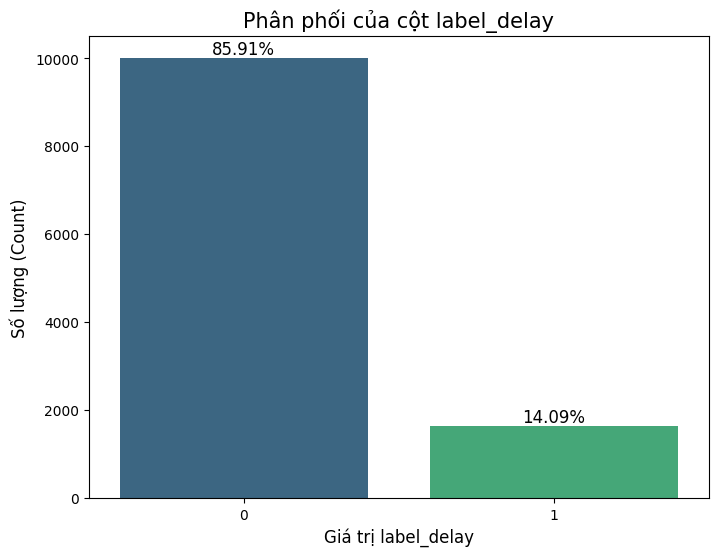

In [11]:
plt.figure(figsize=(8, 6))

# 2. Vẽ biểu đồ countplot (đếm số lượng từng loại)
ax = sns.countplot(x='label_delay', data=df_train, palette='viridis')

# 3. Tính toán phần trăm và hiển thị lên đầu mỗi cột
total = len(df_train['label_delay'])
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.2f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=12)

# 4. Thêm tiêu đề và nhãn
plt.title('Phân phối của cột label_delay', fontsize=15)
plt.xlabel('Giá trị label_delay', fontsize=12)
plt.ylabel('Số lượng (Count)', fontsize=12)

# 5. Hiển thị biểu đồ
plt.show()

$\rightarrow$ Dữ liệu bị mất cân bằng nghiêm trọng, tỉ lệ trễ chỉ 14.09%

### Kiểm tra tính Logic

In [12]:
print("--- Kiểm tra tính Logic ---")

# 1. Nhiệt độ không thể thấp hơn điểm sương (vật lý)
physics_error = df_train[df_train['temperature_c'] < df_train['dew_point_c']]
print(f"Số dòng lỗi Nhiệt độ < Điểm sương: {len(physics_error)}")

# 2. Kiểm tra những chuyến bay 'đúng giờ' (label 0) nhưng số phút trễ lại quá lớn
logic_error = df_train[(df_train['label_delay'] == 0) & (df_train['delay_minutes'] > 15)]
print(f"Số dòng lỗi Label=0 nhưng trễ > 15p: {len(logic_error)}")

--- Kiểm tra tính Logic ---
Số dòng lỗi Nhiệt độ < Điểm sương: 0
Số dòng lỗi Label=0 nhưng trễ > 15p: 0


## Phân tích Đơn biến

### Phân tích cột `deplay_minutes` của mô hình

In [13]:
missing_delay = df_train[df_train['delay_minutes'].isnull()]
print("--- Phân tích dòng thiếu delay_minutes ---")
print(missing_delay['status_group'].value_counts())

--- Phân tích dòng thiếu delay_minutes ---
status_group
on_time     1739
landed       111
departed      21
Name: count, dtype: int64


Các dòng `deplay_minutes` bị thiếu nhưng đều có `status_group` là `on_time`, `landed` hoặc `departed`  -> Có thể là chưa cập nhật được dữ liệu về các chuyến bay này cho nên bị thiếu `deplay_minutes` ở các dòng này. Không ảnh hưởng quá lớn đến dataset

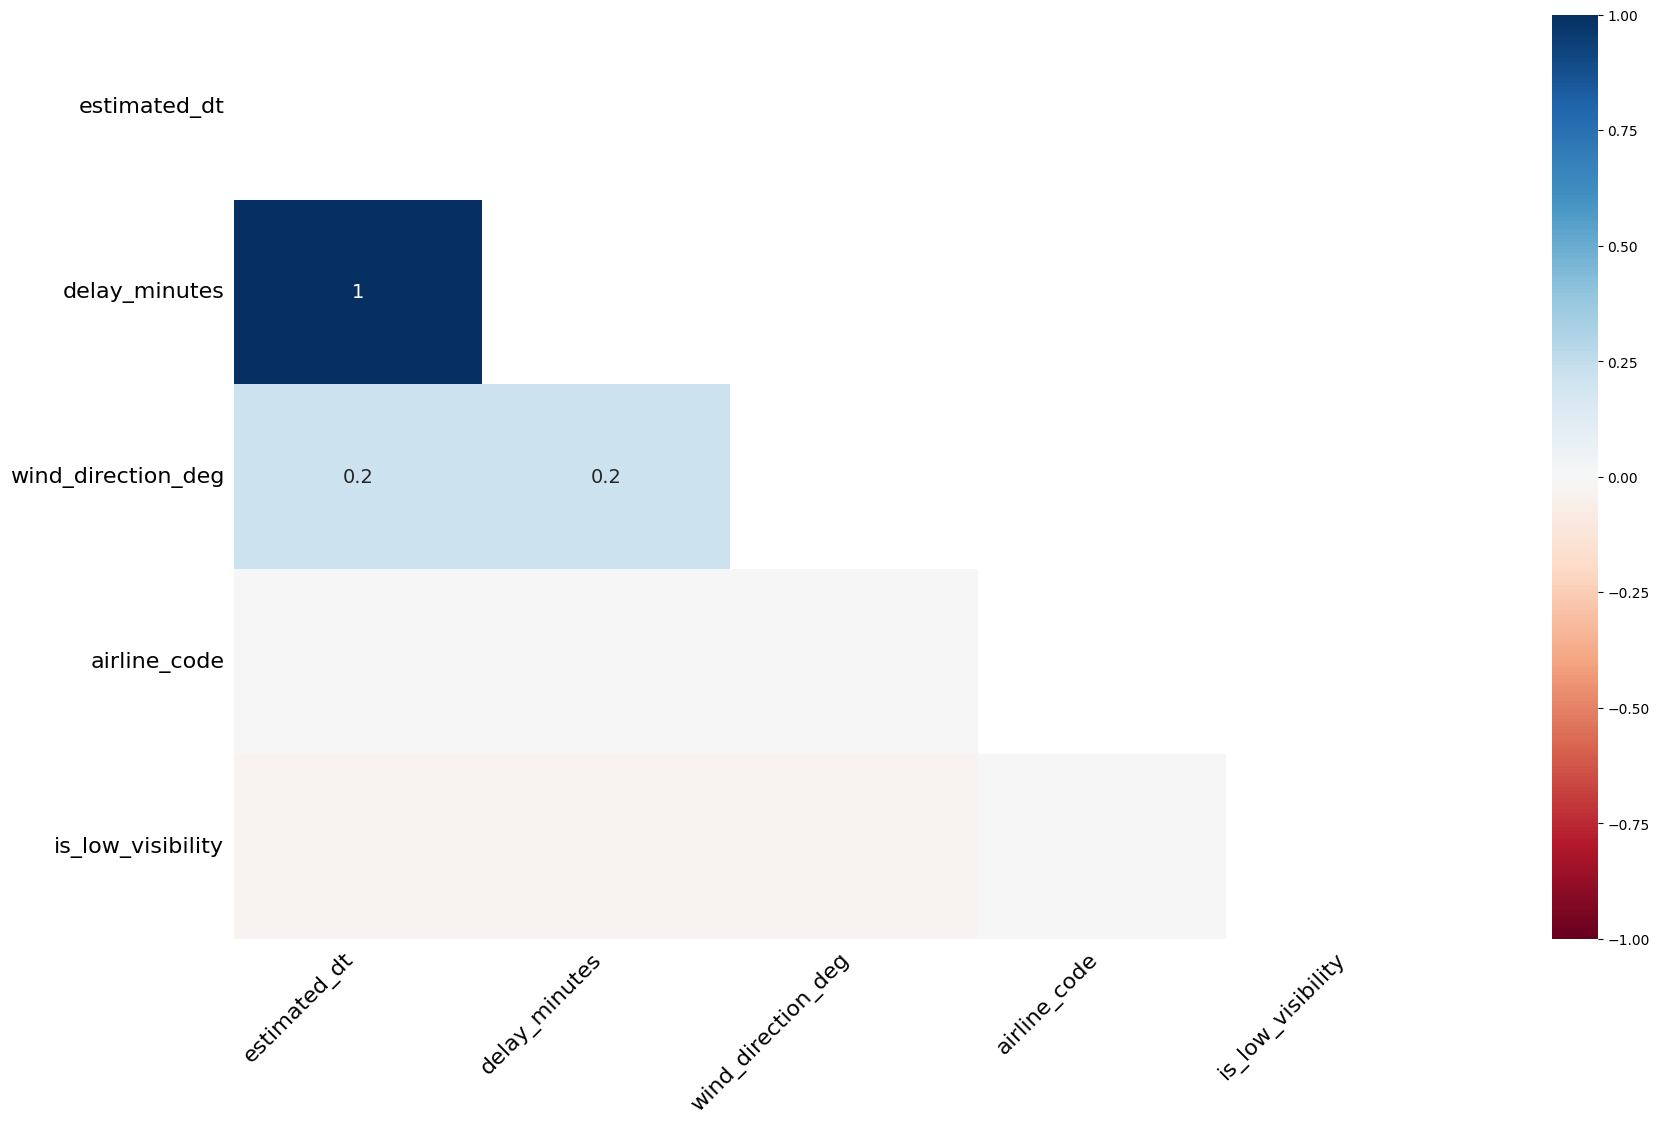

In [14]:
# Kiểm tra các cột có bị thiếu chung 1 lúc hay không
import missingno as msno
msno.heatmap(df_train)
plt.show()

### Phân tích dòng bị thiếu của `is_low_visibility`

In [15]:
# Kiểm tra các dòng bị thiếu is_low_visibility
missing_vis_flag = df_train[df_train['is_low_visibility'].isnull()]

print("Thống kê tầm nhìn (visibility_miles) khi is_low_visibility bị thiếu:")
print(missing_vis_flag['visibility_miles'].describe())

Thống kê tầm nhìn (visibility_miles) khi is_low_visibility bị thiếu:
count    55.0
mean      6.0
std       0.0
min       6.0
25%       6.0
50%       6.0
75%       6.0
max       6.0
Name: visibility_miles, dtype: float64


$\rightarrow$ Dựa theo thống kê mô tả trên, ta thấy các dòng bị thiếu đều có `visibility_miles=6` -> có thể bị lỗi khi đang xử lý dữ liệu -> có thể preprocess lại thêm 1 lần nữa trước khi đưa vào mô hình dự đoán

### Phân tích các dòng bị thiếu của `wind_direction_deg`

So sánh tỉ lệ trễ khi có/không có dữ liệu hướng gió:
missing_wind
0    0.150294
1    0.088650
Name: label_delay, dtype: float64


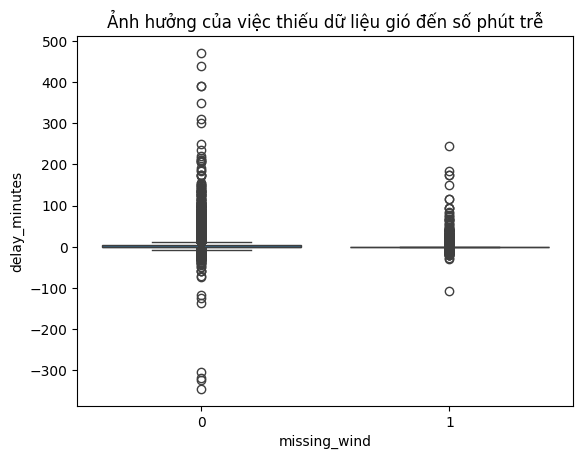

In [16]:
# Tạo một cột tạm thời: 1 nếu thiếu wind_direction, 0 nếu có
df_train['missing_wind'] = df_train['wind_direction_deg'].isnull().astype(int)

# So sánh tỉ lệ trễ (label_delay) hoặc số phút trễ trung bình giữa 2 nhóm
print("So sánh tỉ lệ trễ khi có/không có dữ liệu hướng gió:")
print(df_train.groupby('missing_wind')['label_delay'].mean())

# Hoặc dùng Boxplot để so sánh delay_minutes
sns.boxplot(x='missing_wind', y='delay_minutes', data=df_train)
plt.title('Ảnh hưởng của việc thiếu dữ liệu gió đến số phút trễ')
plt.show()

- Nhóm có đủ dữ liệu (Cột 0): Chứa những ca trễ rất nặng, kéo dài lên tới gần 500 phút và cả những ca đến sớm bất thường (outliers âm). Các chấm tròn (outliers) dày đặc và trải dài.

- Nhóm thiếu dữ liệu (Cột 1): Các điểm outliers thưa thớt hơn hẳn và mức trễ cao nhất chỉ rơi vào khoảng 250 phút.

$\rightarrow$ Nhận xét: Việc có dữ liệu gió dường như đi kèm với những biến động lớn hơn về thời gian bay.

Thông thường trong ngành hàng không, khi dữ liệu hướng gió bị thiếu thường sẽ ghi nhận là tốc độ gió cực thấp hay variable
$\rightarrow$ Khi trời lặng gió thì máy bay cất cánh, hạ cánh đúng giờ hơn, ít bị trễ chuyến. Ta sẽ xem thử liệu biến `is_wind_variable` có liên quan gì đến `wind_direction_deg` hay không

In [17]:
# Kiểm tra xem có phải cứ is_wind_variable == 1 thì wind_dir_deg bị NaN không
check = df_train[df_train['is_wind_variable'] == 1]['wind_direction_deg'].isnull().all()
print(f"Tất cả dòng 'variable' đều bị thiếu hướng gió: {check}")

# Kiểm tra ngược lại: khi is_wind_variable == 0 thì có dòng nào bị NaN không
check_null_when_0 = df_train[df_train['is_wind_variable'] == 0]['wind_direction_deg'].isnull().any()
print(f"Có dòng nào không phải 'variable' mà vẫn mất hướng gió không: {check_null_when_0}")

Tất cả dòng 'variable' đều bị thiếu hướng gió: True
Có dòng nào không phải 'variable' mà vẫn mất hướng gió không: False


$\rightarrow$ Các dòng có `wind_direction_deg=NaN` thì `is_wind_variable=1`

### Phân tích Phân phối và Độ lệch

Skewness của delay_minutes: 4.60
Skewness của temperature_c: 0.58
Skewness của wind_speed_kt: 0.31
Skewness của visibility_miles: -3.17
Skewness của scheduled_hour: -0.19


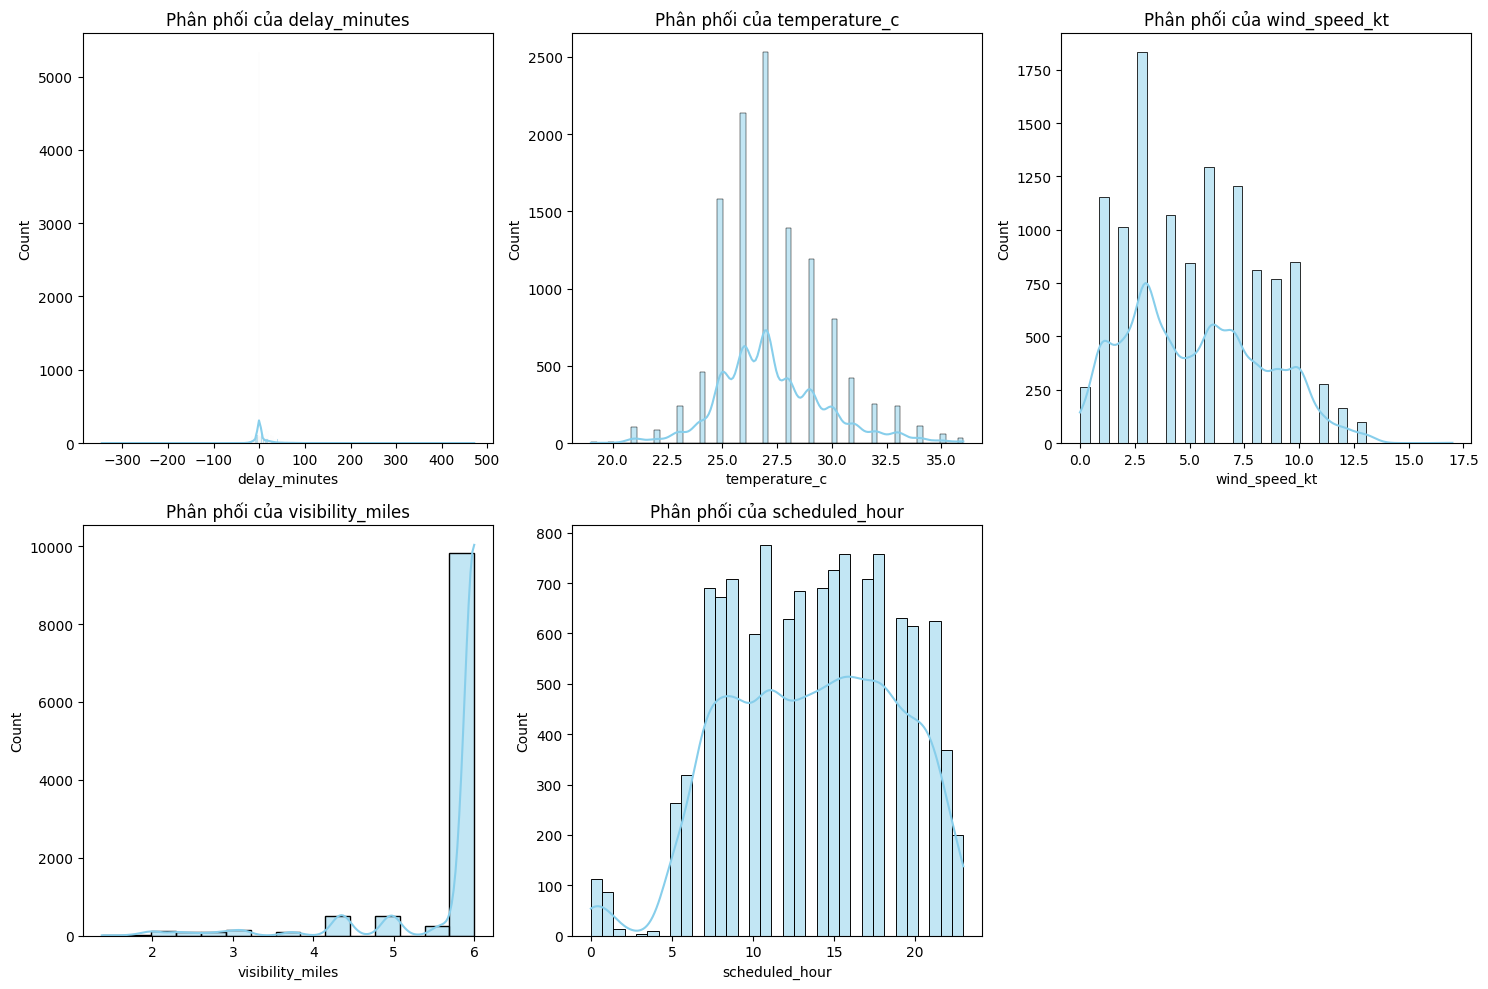

In [18]:
# Danh sách các cột số cần kiểm tra
num_cols = ['delay_minutes', 'temperature_c', 'wind_speed_kt', 'visibility_miles', 'scheduled_hour']

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df_train[col], kde=True, color='skyblue')
    plt.title(f'Phân phối của {col}')
    # Tính độ lệch (Skewness)
    print(f"Skewness của {col}: {df_train[col].skew():.2f}")

plt.tight_layout()
plt.show()

`delay_minutes`: Bị lệch phải nghiêm trọng do có các outlier gần 500 -> độ lệch bị kéo về bên phải nhiều hơn dù cho có các giá trị âm (-345).

`temperature_c`: Lệch phải vừa phải. Đa số nhiệt độ tập trung quanh mức 26-27°C, nhưng có một số giá trị cao hơn (33-36°C) làm phân phối hơi lệch về bên phải.

`wind_speed_kt`: Lệch phải rõ rệt. Phần lớn thời gian là gió nhẹ (0-3 knot), nhưng có một vài trường hợp gió mạnh (lên tới 13-14 knot) tạo thành đuôi dài bên phải.

`visibility_miles`: Lệch trái rất mạnh. Điều này dễ hiểu vì đa số các chuyến bay có tầm nhìn tối đa (6 dặm), chỉ một số ít trường hợp tầm nhìn thấp mới kéo đuôi về bên trái.

`scheduled_hour`: Khá đối xứng, hơi lệch trái nhẹ, cho thấy các chuyến bay được phân bổ rất đều và cân bằng qua các khung giờ trong ngày (hơi thiên về mức sau 5h sáng).

## Phân tích Đa biến

### Phân tích tương quan

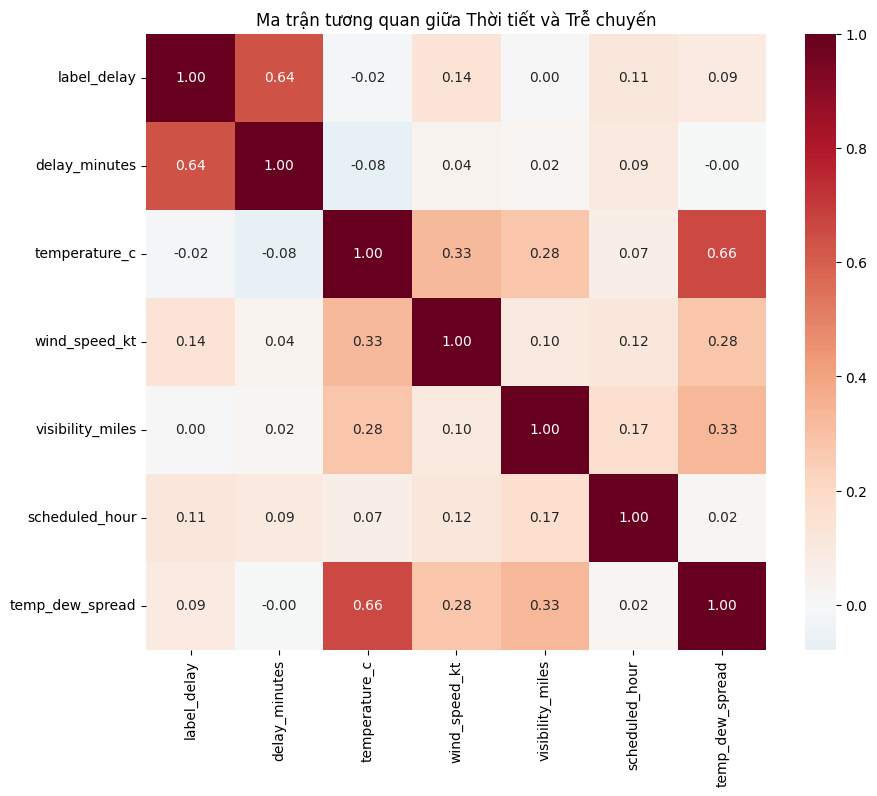

In [19]:
# Chọn các cột số quan trọng
corr_cols = ['label_delay', 'delay_minutes', 'temperature_c', 'wind_speed_kt', 
             'visibility_miles', 'scheduled_hour', 'temp_dew_spread']

plt.figure(figsize=(10, 8))
correlation_matrix = df_train[corr_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0, fmt=".2f")
plt.title('Ma trận tương quan giữa Thời tiết và Trễ chuyến')
plt.show()

**Nhận xét:**
**Tương quan mạnh**
- `label_delay` và `delay_minutes`: Đây là mối tương quan thuận mạnh nhất liên quan đến mục tiêu. Điều này hiển nhiên vì chúng cùng mô tả một hiện tượng, nhưng con số không quá cao cho thấy không phải cứ trễ là sẽ trễ rất nhiều phút (có nhiều ca trễ nhẹ vẫn label là trễ).
- `temp_dew_spread` và `temperature_c`: Đây là mức tương quan cao nhất trong bảng. Spread (nhiệt độ trừ điểm sương) phụ thuộc trực tiếp vào nhiệt độ môi trường, nên biến này có thể gây ra hiện tượng đa cộng tuyến (multicollinearity).

**Các yếu tố khác ảnh hưởng đến việc trễ chuyến**
- `wind_speed_kt`: Tốc độ gió có tương quan thuận nhẹ với việc trễ chuyến. Gió càng mạnh, nguy cơ trễ càng tăng.

- `scheduled_hour`: Giờ bay cũng có ảnh hưởng chút ít. Có thể các khung giờ muộn trong ngày tích tụ trễ chuyến từ các chuyến trước đó.

**Tương quan bằng 0**
- `visibility_miles` và `label_delay`: Con số này cực kỳ thú vị! Nó cho thấy tầm nhìn không có mối liên hệ tuyến tính nào với việc trễ chuyến trong bộ dữ liệu này. Có thể do `visibility_miles` có lượng lớn dòng ở mức `6` cho nên không thể thể hiện được mối quan hệ tuyến tính nhưng có thể có mối liên hệ phi tuyến khi đưa vào các mô hình.

### Các Phát hiện Bất thường

C:\Users\vnviv\AppData\Local\Temp\ipykernel_44040\2740879806.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='airline_code', y='delay_minutes', data=df_train, palette='Set3')


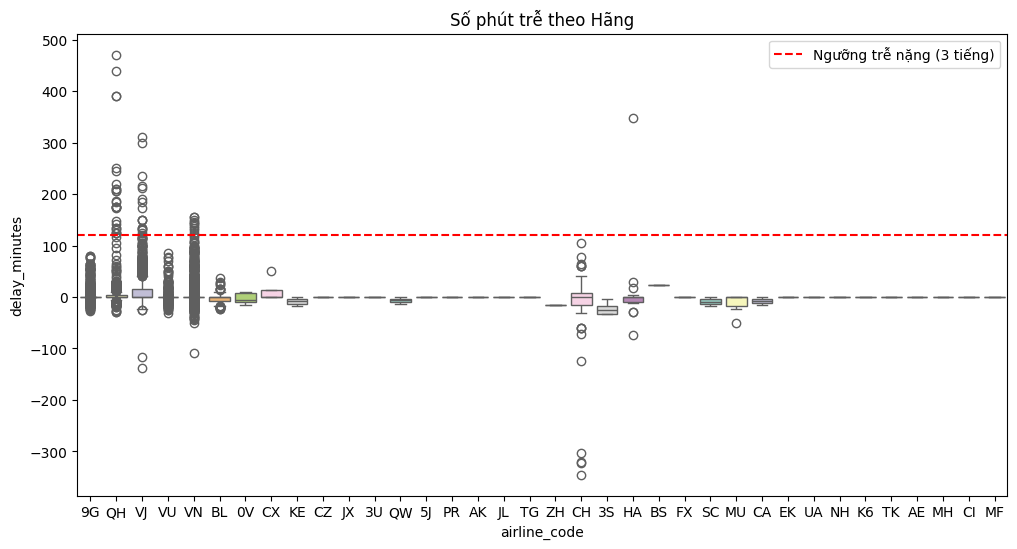

Top 5 chuyến bay trễ nhất
|      | airline_code   |   delay_minutes | status_group   |
|-----:|:---------------|----------------:|:---------------|
| 4277 | QH             |             471 | landed         |
| 4400 | QH             |             440 | departed       |
|   12 | QH             |             390 | delayed        |
|   27 | QH             |             390 | delayed        |
| 5703 | HA             |             348 | landed         |
| 7196 | VJ             |             310 | delayed        |
| 4341 | VJ             |             300 | departed       |
| 4619 | QH             |             250 | departed       |
|  626 | QH             |             245 | on_time        |
| 6097 | VJ             |             235 | delayed        |


In [20]:
plt.figure(figsize=(12, 6))

# Đổi hue thành x để hiện nhãn dưới trục hoành
sns.boxplot(x='airline_code', y='delay_minutes', data=df_train, palette='Set3')

plt.axhline(y=120, color='red', linestyle='--', label='Ngưỡng trễ nặng (3 tiếng)')
plt.title('Số phút trễ theo Hãng')
plt.legend()
plt.show()

# Lọc ra danh sách 5 chuyến bay trễ "kinh khủng" nhất để inspect
outliers_top = df_train.nlargest(10, 'delay_minutes')[['airline_code','delay_minutes', 'status_group']]
print("Top 5 chuyến bay trễ nhất")
print(outliers_top.to_markdown())

**Nhận xét từ biểu đồ Boxplot**
- Các hãng có nhiều outlier nhất: `QH`, `VJ`, `VN` là 3 hãng có dữ liệu biến động nhất. Các chấm tròn phía trên đường outlier xuất hiện dày đặc, chứng tỏ việc trễ chuyến ở các hãng này không phải là hiếm gặp.

- Ngưỡng trễ nặng: Đường gạch đỏ ở mức 120 phút (2 tiếng) đóng vai trò là một mốc phân loại quan trọng. Đa số các hãng nhỏ hoặc quốc tế (như KE, CX, JX...) đều nằm dưới đường này, trong khi `QH`, `VJ`, `VN` có rất nhiều điểm vượt xa ngưỡng này.

- Ta thấy hãng `CH` nắm outlier âm mà đã được nhắc đến (-345). Có thể được dời lịch lên nhưng chưa update trên hệ thống gây ra lỗi snapshot.

**Các chuyến bay có thời tiết tốt nhưng bị label là trễ chuyến**

In [21]:
# Lọc các chuyến trễ nặng trong điều kiện thời tiết tốt
operational_anomalies = df_train[
    (df_train['label_delay'] == 1) & 
    (df_train['visibility_miles'] >= 6) & 
    (df_train['wind_speed_kt'] < 10)
]
print(f"Số lượng bất thường vận hành: {len(operational_anomalies)}")

Số lượng bất thường vận hành: 1138


In [22]:
print(f"Số lượng bất thường trong vận hành của các chuyến bay:\n{operational_anomalies['airline_code'].value_counts()}")

Số lượng bất thường trong vận hành của các chuyến bay:
airline_code
VJ    680
VN    256
9G     87
QH     67
VU     26
CH     12
BL      6
HA      2
CX      1
Name: count, dtype: int64


In [23]:
# Kiểm tra ngày và giờ của các ca bất thường
operational_anomalies[['flight_date', 'scheduled_hour', 'delay_minutes', 'label_delay']].describe()

,scheduled_hour,delay_minutes,label_delay
count,1138.000000,1138.000000,1138.0
mean,14.821617,38.376977,1.0
std,5.125238,34.943796,0.0
min,0.000000,15.000000,1.0
25%,12.000000,20.000000,1.0
50%,15.000000,27.000000,1.0
75%,19.000000,45.000000,1.0
max,23.000000,390.000000,1.0


**Nhận xét:** Ta thấy ở điều kiện thời tiết thuận lời như `visibility_miles >= 6` và `wind_speed_kt <=10` thì có đến 1138 trường hợp chuyến bay bị đánh dấu là trễ

$\rightarrow$ Không thể nhận định là các yếu tố thời tiết là nhân tố duy nhất dẫn đến việc các chuyến bay bị trễ có thể dựa vào nhận định sau:

- Các ca trễ do vận hành ít khi xảy ra vào buổi sáng sớm mà tập trung mạnh vào buổi chiều và tối (75% số ca trễ xảy ra trước 19:00). Điều này gợi ý về hiệu ứng dây chuyền: một chuyến bay trễ dây chuyền từ các chuyến trước đó trong ngày do các vấn đề như vệ sinh tàu bay, bốc xếp hành lý hoặc chuẩn bị phi hành đoàn.

### Phân tích xu hướng theo thời gian

**Tỉ lệ trễ theo các giờ trong ngày**

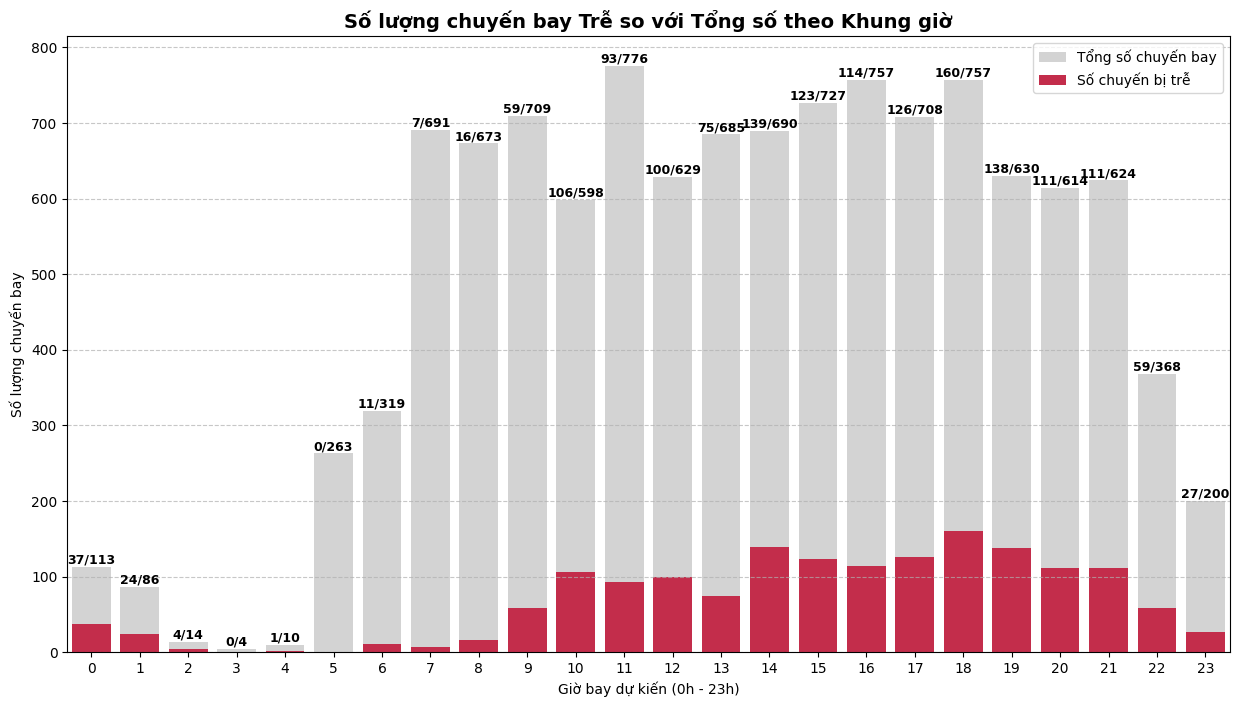

In [24]:
hourly_counts = df_train.groupby(['scheduled_hour', 'label_delay']).size().unstack(fill_value=0)
hourly_counts.columns = ['Đúng giờ', 'Trễ']
hourly_counts['Tổng số'] = hourly_counts['Đúng giờ'] + hourly_counts['Trễ']

# 2. Vẽ biểu đồ
plt.figure(figsize=(15, 8))

# Vẽ cột "Tổng số" trước (màu nhạt hơn)
sns.barplot(x=hourly_counts.index, y=hourly_counts['Tổng số'], color='lightgrey', label='Tổng số chuyến bay')

# Vẽ chồng cột "Trễ" lên trên (màu đậm/nổi bật)
sns.barplot(x=hourly_counts.index, y=hourly_counts['Trễ'], color='crimson', label='Số chuyến bị trễ')

# 3. Thêm nhãn số lượng trên đầu mỗi cột để dễ quan sát
for i, total in enumerate(hourly_counts['Tổng số']):
    delay = hourly_counts['Trễ'].iloc[i]
    # Hiển thị: Số trễ / Tổng số
    plt.text(i, total + 0.5, f'{delay}/{total}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.title('Số lượng chuyến bay Trễ so với Tổng số theo Khung giờ', fontsize=14, fontweight='bold')
plt.xlabel('Giờ bay dự kiến (0h - 23h)')
plt.ylabel('Số lượng chuyến bay')
plt.legend()
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

**Hiệu ứng dây chuyền**
- Từ 5h - 8h: Đây là lúc sân bay vận hành tốt nhất. Dù số lượng chuyến bay bắt đầu tăng vọt (lên tới gần 700 chuyến vào lúc 7h-8h), nhưng số ca trễ lại cực thấp (chỉ 7-16 chuyến). Điều này cho thấy khi bắt đầu ngày mới, mọi thứ đều sẵn sàng và đúng tiến độ.

- Bắt đầu từ 9h sáng, số ca trễ tăng dần và duy trì ở mức cao (trên 100 chuyến mỗi khung giờ) suốt từ 10h sáng đến tận 21h đêm.

**Điểm trễ nhất**:
- Đỉnh điểm trễ chuyến: Khung giờ 18h (6 giờ chiều) là thời điểm tồi tệ nhất về số lượng với 160 chuyến bị trễ trên tổng số 757 chuyến.

- Nhận xét: Đây là lúc hiệu ứng dây chuyền từ các chuyến bay sáng và trưa đạt đến đỉnh điểm. Các chuyến bay trễ tích tụ vào bữa trưa đã đạt đỉnh điểm vào khung 18h

**Các chuyến bay đêm**
- Tỉ lệ trễ cao đột biến: Tuy tổng số chuyến bay lúc 0h chỉ có 113, nhưng có tới 37 chuyến trễ (chiếm khoảng 32.7%). Tương tự lúc 1h sáng là gần 28%.

- Nhận xét: Đây thường không phải là những chuyến bay dự kiến bay lúc 0h bị trễ, mà khả năng cao là những chuyến bay của ngày hôm trước bị dồn lại, đẩy giờ bay thực tế sang ngày mới.

**Những khung giờ an toàn**
- Từ 5-8h là khung giờ an toàn vì tỉ lệ chuyến bay ở đây cực thấp.

**Tỉ lệ trễ theo các ngày trong tuần**

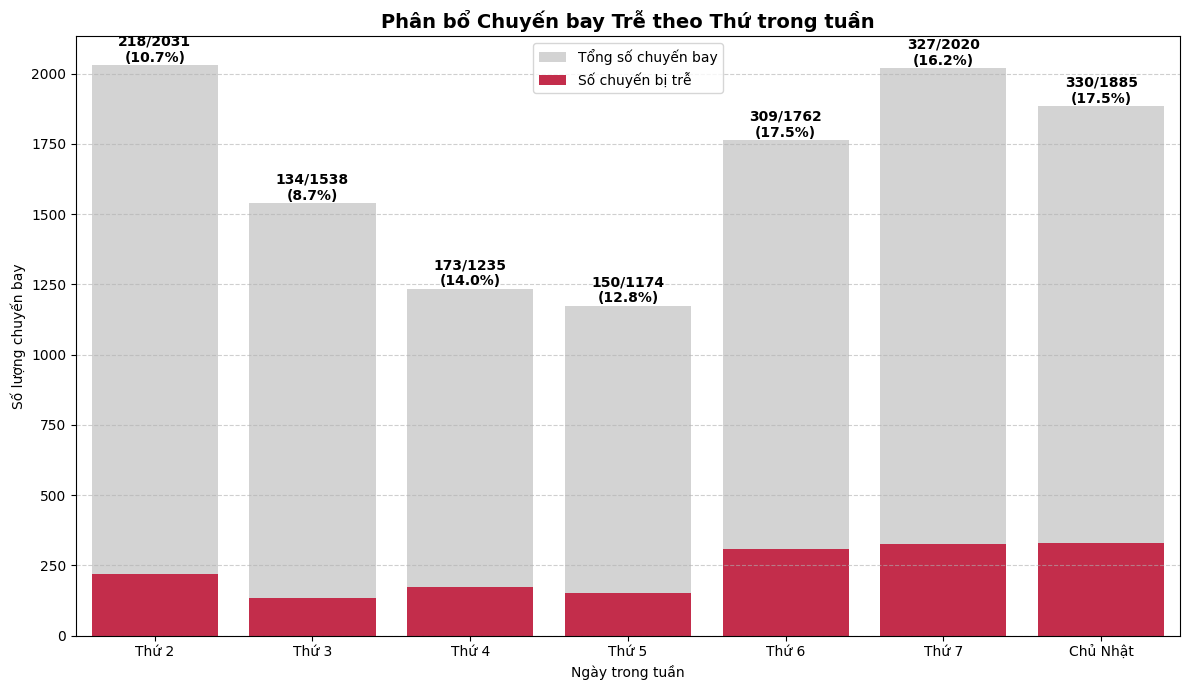

In [25]:
weekly_counts = df_train.groupby(['scheduled_dayofweek', 'label_delay']).size().unstack(fill_value=0)
weekly_counts.columns = ['Đúng giờ', 'Trễ']
weekly_counts['Tổng số'] = weekly_counts['Đúng giờ'] + weekly_counts['Trễ']
weekly_counts = weekly_counts.reindex(range(7), fill_value=0)

day_labels = ['Thứ 2', 'Thứ 3', 'Thứ 4', 'Thứ 5', 'Thứ 6', 'Thứ 7', 'Chủ Nhật']

# 2. Vẽ biểu đồ
plt.figure(figsize=(12, 7))

# Vẽ cột "Tổng số" (Màu xám nhạt làm nền)
sns.barplot(x=weekly_counts.index, y=weekly_counts['Tổng số'], color='lightgrey', label='Tổng số chuyến bay')

# Vẽ chồng cột "Trễ" (Màu cam hoặc đỏ để nhấn mạnh)
sns.barplot(x=weekly_counts.index, y=weekly_counts['Trễ'], color='crimson', label='Số chuyến bị trễ')

# 3. Thêm nhãn số lượng và Tỷ lệ % trên đầu mỗi cột
for i, total in enumerate(weekly_counts['Tổng số']):
    delay = weekly_counts['Trễ'].iloc[i]
    rate = (delay / total) * 100
    # Hiển thị: Số trễ / Tổng số (Tỷ lệ %)
    plt.text(i, total + 1, f'{delay}/{total}\n({rate:.1f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('Phân bổ Chuyến bay Trễ theo Thứ trong tuần', fontsize=14, fontweight='bold')
plt.xlabel('Ngày trong tuần')
plt.ylabel('Số lượng chuyến bay')
plt.xticks(ticks=range(7), labels=day_labels)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

**Tỉ lệ trễ chuyến cao ở cuối tuần**
- Cuối tuần không chỉ là lúc lưu lượng khách tăng cao mà còn là thời điểm các quy trình vận hành dễ bị quá tải nhất. Điều này khớp với biểu đồ khung giờ trước đó về sự tích tụ sai số theo thời gian.

**Tỉ lệ trễ thấp nhấp**
- Thứ 3 là ngày có tỉ lệ trễ thấp nhất trong tuần, chỉ 8.7% (134 trên 1.538 chuyến).

- Nhận xét: Sau áp lực của ngày Thứ 2, Thứ 3 dường như là lúc hệ thống vận hành trơn tru và ổn định nhất trước khi bắt đầu tăng nhiệt trở lại vào giữa tuần.

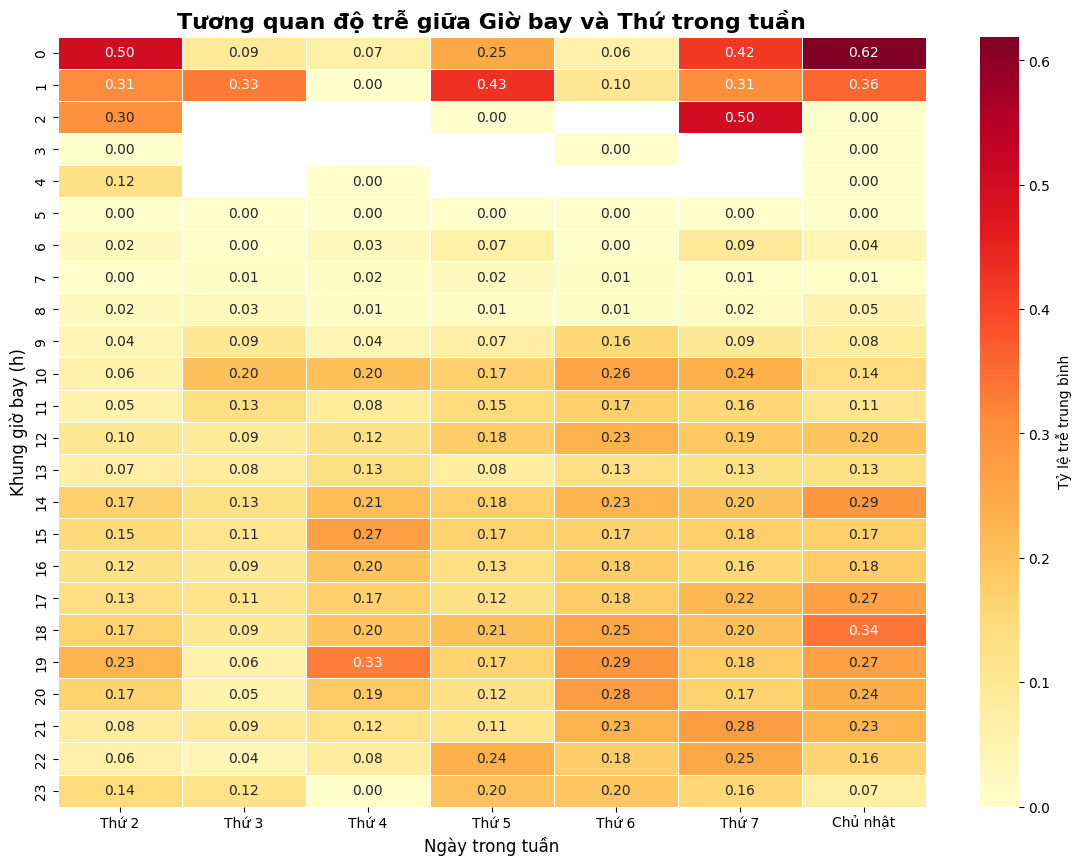

In [26]:
heatmap_data = df_train.groupby(['scheduled_hour', 'scheduled_dayofweek'])['label_delay'].mean().unstack()

day_map = {
    0: 'Thứ 2', 1: 'Thứ 3', 2: 'Thứ 4', 
    3: 'Thứ 5', 4: 'Thứ 6', 5: 'Thứ 7', 6: 'Chủ nhật'
}

heatmap_data = heatmap_data.rename(columns=day_map)

plt.figure(figsize=(14, 10))

# Vẽ heatmap
sns.heatmap(heatmap_data, 
            annot=True,
            fmt=".2f",
            cmap="YlOrRd",
            linewidths=.5,
            cbar_kws={'label': 'Tỷ lệ trễ trung bình'})

# Thêm tiêu đề và nhãn
plt.title('Tương quan độ trễ giữa Giờ bay và Thứ trong tuần', fontsize=16, fontweight='bold')
plt.xlabel('Ngày trong tuần', fontsize=12)
plt.ylabel('Khung giờ bay (h)', fontsize=12)

plt.show()

**Tỉ lệ trễ tích tụ lúc 0-2h sáng**
- Chủ Nhật (0h): Đạt đỉnh 0.62 (62% chuyến bay bị trễ).

- Thứ 2 (0h): Tỷ lệ trễ là 0.50.

- Thứ 7 (2h): Tỷ lệ trễ vọt lên 0.50.

- Nhận xét: Đây là bằng chứng thép cho thấy các chuyến bay đêm muộn thực chất là "nạn nhân" của sự tích tụ trễ chuyến từ cả ngày hôm trước.

**Vùng an toàn (5-8h)**
- Hầu hết các ô đều có màu vàng nhạt với chỉ số cực thấp (gần như 0.00 đến 0.02).

- Đặc biệt là Thứ 3 và Thứ 5 lúc 5h-7h sáng gần như không ghi nhận ca trễ nào đáng kể.

- Nhận xét: Đây là lúc hệ thống vận hành vừa được khởi động lại, máy bay và phi hành đoàn sẵn sàng nhất.

**Sự chuyển biến ở buổi chiều**
- Màu sắc bắt đầu đậm dần (từ vàng sang cam) rõ rệt từ sau 14h và kéo dài đến 21h.

- Thứ 6, Thứ 7, Chủ Nhật: Có dải màu cam đậm bao phủ rộng hơn ở các khung giờ chiều tối (tỷ lệ thường xuyên ở mức 0.20 - 0.34).

- Thứ 4 lúc 19h: Có một điểm nhấn bất ngờ với tỷ lệ 0.33, cao hơn hẳn so với các ngày thường khác trong cùng khung giờ.

- Nhận xét: điều này hoàn toàn đúng với những nhận xét ở các biểu đồ trên, lượng chuyến bay trễ tập trung vào khoảng lúc chiều tối (14h - 21h) và đỉnh điểm vào các ngày cuối tuần.

**Phân tích `wind_speed_kt` có ảnh hưởng đến độ trễ chuyến không do corr có tiềm năng**

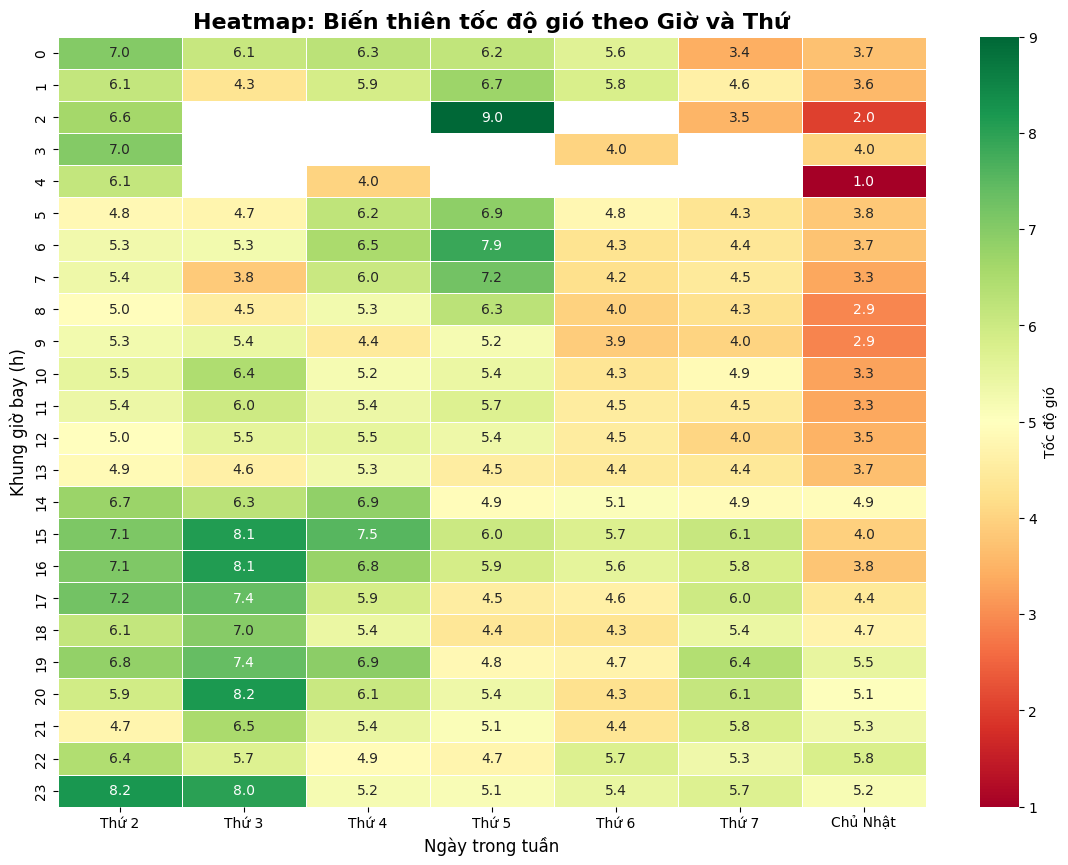

In [27]:
visibility_heatmap = df_train.groupby(['scheduled_hour', 'scheduled_dayofweek'])['wind_speed_kt'].mean().unstack()

# 2. Mapping lại nhãn ngày để khớp với dữ liệu thực tế (tránh lỗi Length mismatch)
day_map = {0: 'Thứ 2', 1: 'Thứ 3', 2: 'Thứ 4', 3: 'Thứ 5', 4: 'Thứ 6', 5: 'Thứ 7', 6: 'Chủ Nhật'}
visibility_heatmap = visibility_heatmap.rename(columns=day_map)

# 3. Vẽ biểu đồ
plt.figure(figsize=(14, 10))

# Sử dụng bảng màu RdYlGn (Red-Yellow-Green) 
# Màu Đỏ (Thấp) = Tầm nhìn kém (Nguy hiểm)
# Màu Xanh (Cao) = Tầm nhìn tốt (An toàn)
sns.heatmap(visibility_heatmap, 
            annot=True, 
            fmt=".1f", 
            cmap="RdYlGn", 
            linewidths=.5,
            cbar_kws={'label': 'Tốc độ gió'})

plt.title('Heatmap: Biến thiên tốc độ gió theo Giờ và Thứ', fontsize=16, fontweight='bold')
plt.xlabel('Ngày trong tuần', fontsize=12)
plt.ylabel('Khung giờ bay (h)', fontsize=12)

plt.show()

**Ngày chủ nhật**
- Về gió: Chủ Nhật là ngày có tốc độ gió thấp nhất trong tuần (vùng màu cam/đỏ chiếm đa số, dao động từ 2.0 đến 4.0 knots).

- Về trễ chuyến: Ngược lại, Chủ Nhật lại có tỉ lệ trễ cao nhất, đặc biệt là lúc 0h (0.62) và các khung giờ chiều tối (0.27 - 0.34).

=> Kết luận: Tốc độ gió không phải là thủ phạm chính gây trễ chuyến vào cuối tuần. Điều này củng cố giả thuyết rằng trễ chuyến vào Chủ Nhật chủ yếu do áp lực vận hành và lưu lượng hành khách quá tải (Weekend Effect).

**Ổn định của hệ thống trước tốc độ gió**
- Về gió: Thứ 3 và Thứ 5 ghi nhận những đợt gió mạnh nhất (vùng màu xanh đậm), đặc biệt là chiều Thứ 3 (8.1 - 8.2 knots) và sáng Thứ 5 (7.2 - 7.9 knots).

- Về trễ chuyến: Tuy gió mạnh, nhưng tỉ lệ trễ ở các khung giờ này vẫn duy trì ở mức thấp hoặc trung bình (0.05 - 0.17).

=> Kết luận: Các hãng hàng không có vẻ kiểm soát rất tốt các tác động từ gió trong tầm 8 knots. Gió ở mức này chưa đủ để làm khó quy trình cất/hạ cánh tiêu chuẩn.

### So sánh biến mục tiêu với các biến thành phần

**So sánh `airline_code` với `label_delay`**

C:\Users\vnviv\AppData\Local\Temp\ipykernel_44040\1071357754.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


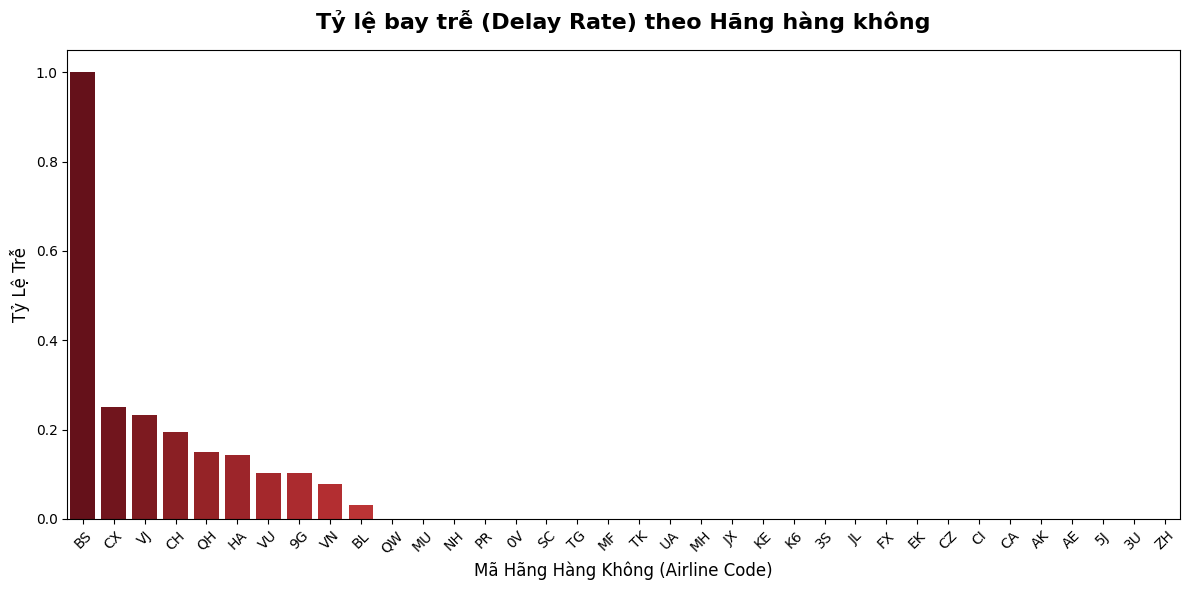

In [28]:
airline_check = df_train.groupby('airline_code').agg(
    total_flight=('label_delay', 'count'),
    delay_rate=('label_delay', 'mean')
).reset_index()

# Sắp xếp giảm dần theo delay_rate để biểu đồ đẹp hơn
airline_check = airline_check.sort_values(by='delay_rate', ascending=False)

# 2. Bắt đầu vẽ biểu đồ
plt.figure(figsize=(12, 6)) # Thiết lập kích thước khung hình (rộng 12, cao 6)

# Sử dụng seaborn để vẽ biểu đồ cột
# Đặt x là hãng hàng không, y là tỷ lệ trễ
sns.barplot(
    data=airline_check, 
    x='airline_code', 
    y='delay_rate', 
    palette='Reds_r' # Dùng dải màu đỏ (Reds_r: dải màu đỏ nhạt dần) để nhấn mạnh sự "trễ"
)

# 3. Thêm tiêu đề và làm đẹp các nhãn
plt.title('Tỷ lệ bay trễ (Delay Rate) theo Hãng hàng không', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Mã Hãng Hàng Không (Airline Code)', fontsize=12)
plt.ylabel('Tỷ Lệ Trễ', fontsize=12)

# Xoay chữ ở trục X đi 45 độ để không bị đè lên nhau nếu có quá nhiều hãng
plt.xticks(rotation=45) 

# Tự động căn chỉnh khoảng cách để hình không bị cắt chữ
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()

=> Ta sẽ ưu tiên phân tích 4 hãng máy bay `QH`, `VJ`, `9G`, `VN` về độ trễ chuyến cũng như tỉ trọng chuyến bay.

In [29]:
def inspect_airlines_weather(df, airline_list):
    summary = []
    
    for code in airline_list:
        # Lọc dữ liệu theo hãng
        airline_df = df[df['airline_code'] == code]
        
        # Định nghĩa điều kiện thời tiết
        good_weather_mask = (airline_df['visibility_miles'] >= 5) & (airline_df['wind_speed_kt'] <= 10)
        
        # Tính toán tỷ lệ
        good_rate = airline_df[good_weather_mask]['label_delay'].mean() * 100
        bad_rate = airline_df[~good_weather_mask]['label_delay'].mean() * 100
        
        summary.append({
            'Hãng': code,
            'Trời ĐẸP (%)': round(good_rate, 2),
            'Trời XẤU (%)': round(bad_rate, 2),
            'Chênh lệch (%)': round(bad_rate - good_rate, 2)
        })
    
    return pd.DataFrame(summary)

# Chạy thử với 3 hãng lớn
airlines_to_check = ['VN', 'VJ', 'QH', '9G']
comparison_df = inspect_airlines_weather(df_train, airlines_to_check)
comparison_df

,Hãng,Trời ĐẸP (%),Trời XẤU (%),Chênh lệch (%)
0,VN,7.22,10.81,3.59
1,VJ,22.65,26.63,3.98
2,QH,14.29,17.76,3.47
3,9G,10.36,9.40,-0.96


- `VJ` trễ do vận hành là chính: thời tiết chỉ là yếu tố cộng hưởng làm tệ thêm tình hình (tăng thêm ~4%), còn nguyên nhân gốc rễ nằm ở khâu vận hành, lịch trình hoặc quay đầu tàu bay. Tương tự đối với `QH`

- `VN` kiểm soát vận hành rất tốt (7%): ảnh hưởng do yếu tố thời tiết khiến tỉ lệ trễ tăng thêm gần 4%

- `9G` thì lại ngược lại tỉ lệ trễ khi trời đẹp lại cao hơn khi trời xấu cho thấy hãng có khả năng xử lý khi trời xấu nhưng do bị quá tải chuyến bay khiến cho dù trời đẹp cũng có thể bị trễ.

**Tỉ lệ trễ của 4 hãng theo xu hướng**

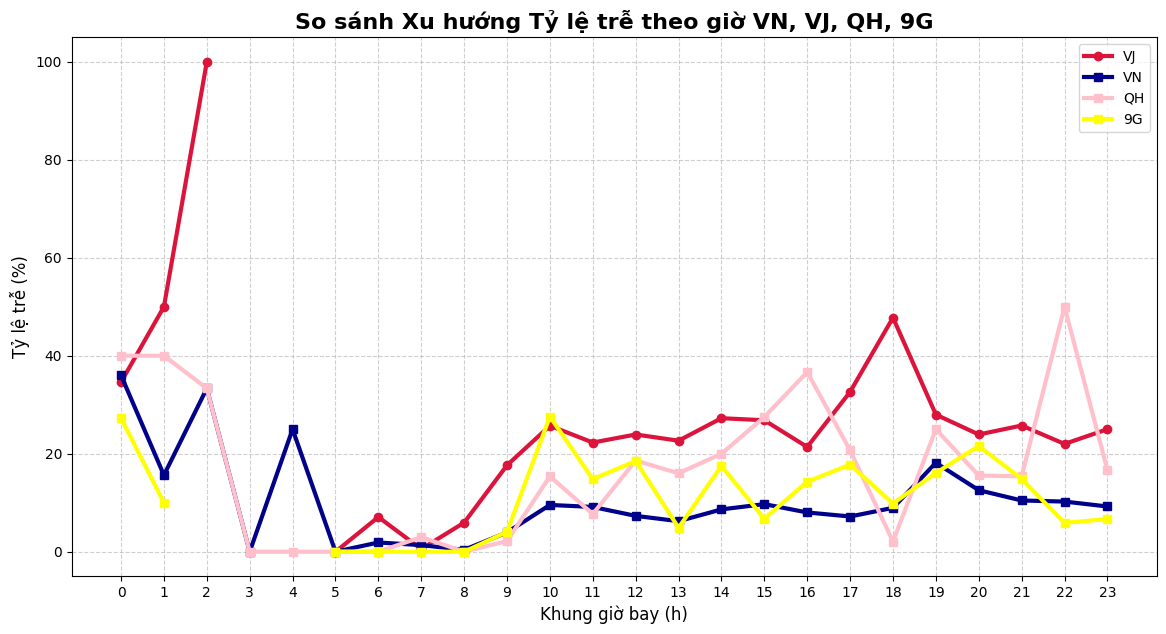

In [30]:
vj_vn_df = df_train[df_train['airline_code'].isin(['VJ', 'VN', 'QH', '9G'])]

# 2. Tính tỷ lệ trễ theo giờ cho từng hãng
hourly_comparison = vj_vn_df.groupby(['scheduled_hour', 'airline_code'])['label_delay'].mean().unstack() * 100

# 3. Vẽ biểu đồ đường để thấy sự khác biệt về xu hướng
plt.figure(figsize=(14, 7))

# Vẽ đường cho VJ
plt.plot(hourly_comparison.index, hourly_comparison['VJ'], marker='o', linewidth=3, color='crimson', label='VJ')
# Vẽ đường cho VN
plt.plot(hourly_comparison.index, hourly_comparison['VN'], marker='s', linewidth=3, color='darkblue', label='VN')

plt.plot(hourly_comparison.index, hourly_comparison['QH'], marker='s', linewidth=3, color='pink', label='QH')

plt.plot(hourly_comparison.index, hourly_comparison['9G'], marker='s', linewidth=3, color='yellow', label='9G')

# Thêm các chi tiết biểu đồ
plt.title('So sánh Xu hướng Tỷ lệ trễ theo giờ VN, VJ, QH, 9G', fontsize=16, fontweight='bold')
plt.xlabel('Khung giờ bay (h)', fontsize=12)
plt.ylabel('Tỷ lệ trễ (%)', fontsize=12)
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

Hãng `VJ`:
- Có tỉ lệ trễ cao nhất và biến động mạnh nhất trong hầu hết các khung giờ và đều duy trì ở mức cao (10h sáng đến 2h sáng hôm sau).

- Đáng chú ý là đỉnh 100% vào lúc 2h sáng, có thể do số lượng chuyến bay vào giờ này cực ít nên chỉ cần một ca trễ là kéo tỉ lệ lên mức tuyệt đối.

Hãng `VN`:

- Đây là hãng có phong độ ổn định nhất với tỉ lệ trễ thấp hơn hẳn so với các hãng khác.

- Đa số thời gian trong ngày, VN giữ tỉ lệ trễ dưới 15%, ngoại trừ lúc nửa đêm (0h) và rạng sáng (4h).

Hãng `QH`:

- Có xu hướng trễ rất cao vào rạng sáng (0h-2h) và đạt đỉnh mới vào cuối ngày lúc 22h (~50%).

- Điểm kỳ lạ là tỉ lệ trễ rơi về gần 0% vào lúc 18h, trái ngược hoàn toàn với `VJ`.

Hãng `9G`:

- Nằm ở mức trung bình, thường dao động quanh ngưỡng 10% - 20% vào buổi chiều.

- Có một đỉnh trễ khá rõ rệt vào lúc 10h sáng (~28%).

C:\Users\vnviv\AppData\Local\Temp\ipykernel_44040\1834470573.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=vj_contribution.values, y=vj_contribution.index, palette='Reds_r')


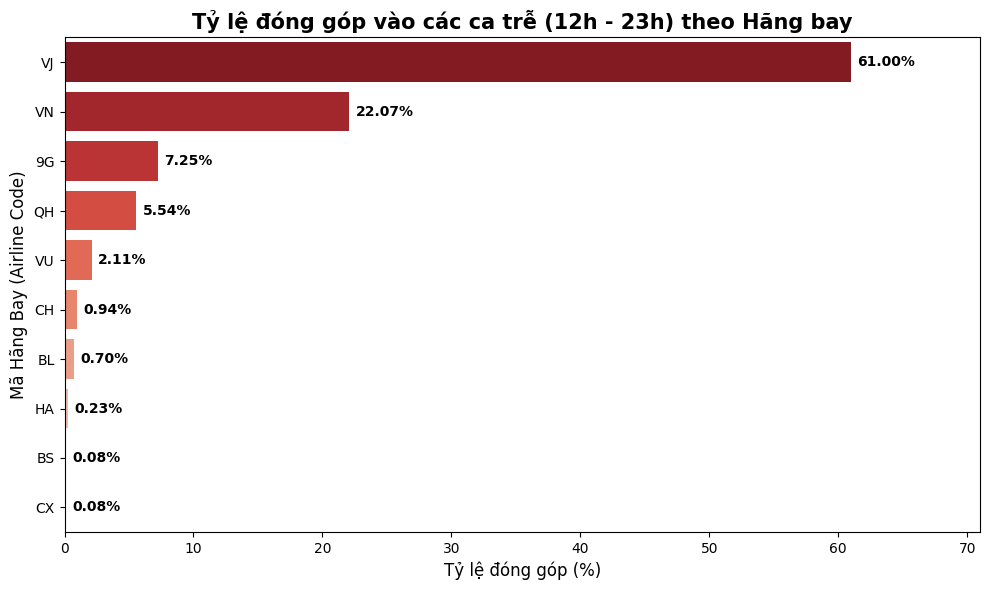

In [31]:
night_flights = df_train[(df_train['scheduled_hour'] >= 12) & (df_train['scheduled_hour'] <= 23)]
vj_contribution = night_flights[night_flights['label_delay'] == 1]['airline_code'].value_counts(normalize=True) * 100

# 2. Vẽ biểu đồ
plt.figure(figsize=(10, 6))

# Vẽ biểu đồ cột ngang (barplot)
# Sử dụng bảng màu 'Reds_r' (Đỏ) để nhấn mạnh mức độ nghiêm trọng của trễ chuyến
ax = sns.barplot(x=vj_contribution.values, y=vj_contribution.index, palette='Reds_r')

plt.title('Tỷ lệ đóng góp vào các ca trễ (12h - 23h) theo Hãng bay', fontsize=15, fontweight='bold')
plt.xlabel('Tỷ lệ đóng góp (%)', fontsize=12)
plt.ylabel('Mã Hãng Bay (Airline Code)', fontsize=12)

# Thêm giá trị % trực tiếp lên cạnh mỗi cột cho dễ nhìn
for i, v in enumerate(vj_contribution.values):
    ax.text(v + 0.5, i, f'{v:.2f}%', color='black', va='center', fontweight='bold')

# Nới rộng trục X để số không bị lẹm
plt.xlim(0, max(vj_contribution.values) + 10) 
plt.tight_layout()
plt.show()

**Nhận xét:** Điều này cho thấy rõ số chuyến trễ của hãng `VJ` ảnh hưởng rất lớn đối với tỉ lệ trễ theo xu hướng chung. Đa phần sẽ là do thời tiết xấu cộng với việc sắp xếp lịch, sự trễ theo dây chuyền và việc có quá nhiều lịch bay khiến cho hãng `VJ` bị quá tải dẫn đến trễ nhiều.